# Self-Correcting Agentic Retrieval Loops

**Build an agent that reads its own retrieval, then spends only what each query needs.**

Most retrieval agents do the same thing to every query: one fixed pipeline, whether the question
is a trivial lookup or a hard multi-hop chain. Here you build, from Qdrant primitives, a
**self-evaluating agent** that reads cheap in-loop signals and climbs a **cost-escalation ladder**
only as far as it has to:

```
Tier 1  answer        confident? answer now (the cheap path)
Tier 2  ColBERT       weak single-hop lookup? a token-level precision re-retrieval
Tier 3  decompose     weak multi-hop? recover the missing hop (IRCoT)
        then ANSWER or STOP (a separate sufficiency decision)
```

This notebook teaches the **method** *and* how to reproduce it: every retrieval, signal, and
routing decision is real code you can read and run. Nothing core is hidden behind a black box.
`src/` is the same logic packaged for reuse; `src/labkit.py` is rendering only. We run it
end-to-end on a **mixed workload** (single-hop + multi-hop + unanswerable) and report the honest
result: where adaptive routing pays, and where it does not.

Roadmap: **CP1** the hybrid query + baseline, **CP2** compute and benchmark the confidence signal
and build the gate, **CP3** the ColBERT and decompose rungs run live, **the assembled loop** run
end to end, **STOP** the answer-vs-abstain choice, **Wrap** the honest scorecard and how to adapt
this to your workflow.

## Setup

Everything is pre-installed, pre-embedded, and warm on your VM. This cell wires `src/` onto the
path, loads your keys, imports the Qdrant client + helpers, and loads the question set plus the
calibrated gate.

In [12]:
import sys
import os
import json
import statistics
from pathlib import Path

REPO = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(REPO / "src"))

from dotenv import load_dotenv
load_dotenv(REPO / ".env")

import config, data, retrieval, signals, agent
import pandas as pd
from qdrant_client import models
from sklearn.metrics import roc_auc_score
from labkit import (load_artifact, frontier_table, show_hits, show_run,
                    plot_signal_separation, plot_gate)

pd.set_option("display.precision", 3)
client = retrieval.get_client()

main_count = client.count(config.COLLECTION, exact=True).count
assert main_count > 0, "collection empty - run scripts/setup_collections.py"
colbert_count = (client.count(config.COLBERT_COLLECTION, exact=True).count
                 if client.collection_exists(config.COLBERT_COLLECTION) else "absent")
api_keys_loaded = all(os.environ.get(k) for k in ("ANTHROPIC_API_KEY", "OPENAI_API_KEY"))

by_id = {q["id"]: q for q in data.load_questions_mixed()}
th = signals.load_thresholds(path=config.ARTIFACTS_DIR / "thresholds_mixed.json")  # calibrated gate

print(f"Qdrant '{config.COLLECTION}': {main_count} points  |  '{config.COLBERT_COLLECTION}': {colbert_count} points")
print(f"dense ({config.DENSE_MODEL}) + sparse ({config.HYBRID_SPARSE_VEC}), fused with {config.FUSION_METHOD.upper()}")
print(f"loaded {len(by_id)} questions; gate floor dense_variance < {th['dense_variance']:.3f}")
print(f"API keys loaded: {api_keys_loaded}")
print("\nReady" if main_count and api_keys_loaded else "\nNOT ready")

Qdrant 'musique': 22808 points  |  'musique_colbert': 22808 points
dense (BAAI/bge-base-en-v1.5) + sparse (minicoil), fused with RRF
loaded 2612 questions; gate floor dense_variance < 0.039
API keys loaded: True

Ready


## CP1: the hybrid query, the precision regime, and the baseline

Real traffic is **mixed**: easy single-hop lookups, hard multi-hop chains, and unanswerable
questions. The **baseline** is one hybrid retrieve then answer, no loop. The key design choice:
the agent answers from a **focused top-3 context**, so ranking *precision* (recall@1/@3) is what
matters, and it is what gives the corrective tiers room to work.

> **On your data:** set this answer-context size deliberately. At a generous top-10 an easy lookup
> is already solved and there is nothing to fix; at top-3 there is real headroom for the rungs.

First, the retrieval primitive. This is the actual Qdrant **hybrid** query: dense (bge) and sparse
(miniCOIL) prefetched in parallel, then fused with Reciprocal Rank Fusion. We will reuse it
everywhere.

In [13]:
def hybrid_search(question, limit=10):
    # Qdrant hybrid retrieval: dense + miniCOIL prefetched, fused server-side with RRF.
    dense, _bm25, minicoil = retrieval.encode_query(question)   # bge dense + miniCOIL sparse
    return client.query_points(
        config.COLLECTION,
        prefetch=[
            models.Prefetch(query=dense, using=config.DENSE_VEC, limit=50),
            models.Prefetch(
                query=models.SparseVector(indices=minicoil.indices.tolist(),
                                          values=minicoil.values.tolist()),
                using=config.MINICOIL_VEC, limit=50),
        ],
        query=models.FusionQuery(fusion=models.Fusion.RRF),
        limit=limit, with_payload=True,
    ).points

### Two kinds of query, and why you can't tell them apart up front

Both of these are perfectly normal things a user asks, and on the surface they look the same:

- **Simple (single-hop):** the answer sits in one passage, so a single retrieve can answer it
  right away. *"Which continent is the Atbarah River on?"*
- **Complex (multi-hop):** the answer is spread across passages, and the later ones are not
  reachable from the question as written. The agent has to retrieve, read what came back, and
  retrieve again. *"What sea washes the shores of the birthplace of Jim Wilson?"* needs the
  birthplace before it can ask about the sea.

Nothing on the surface of a question reliably says "this one needs a second hop," so you cannot
sort them up front. That is exactly why the agent reads a cheap signal off its own retrieval (CP2)
and escalates only when the retrieval looks weak, instead of trusting the question.

A single-hop lookup first: the supporting passage is right there, so the agent answers from the
top-3.

In [ ]:
single = by_id["2hop__101521_42157__h0"]
print(f"Q: {single['question']}\n")
show_hits(hybrid_search(single["question"]), single["gold_doc_ids"])

Q: Which continent is Atbarah River located?



Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Fetching 18 files:   0%|          | 0/18 [00:00<?, ?it/s]

Fetching 8 files:   0%|          | 0/8 [00:00<?, ?it/s]

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

Now a multi-hop question, done by hand so you can see what one retrieve can and cannot reach:

> *What sea washes on the shores of the birthplace of Jim Wilson?*

- **Hop 1 (the birthplace):** *Where was Jim Wilson born?* -> County Antrim
- **Hop 2 (the sea):** *What sea washes the shores of County Antrim?* -> Irish Sea

In [ ]:
multi = by_id["2hop__615262_131886"]
gold = set(multi["gold_doc_ids"])

# HOP 1: retrieve the question as written; look deep (top-100) for the second passage.
hop1 = hybrid_search(multi["question"], limit=100)
print(f"Q: {multi['question']}\n")
print("HOP 1 - retrieve the question as written (top-3):")
show_hits(hop1, gold)

missing = gold - {p.id for p in hop1[:3]}
reachable_deep = bool(missing & {p.id for p in hop1})   # hop1 holds the top-100
print(f"supporting passages in the top-3: {len(gold) - len(missing)}/{len(gold)} "
      f"(only the Hop-1 passage, whose snippet names the birthplace).")
print(f"\n the missing Hop-2 passage is {'in' if reachable_deep else 'NOT even in'} the top-100: "
      f"genuinely out of reach, not just mis-ranked.\n")

# HOP 2: ask the follow-up using the bridge entity Hop 1 revealed.
hop2_query = "What sea washes the shores of County Antrim?"
print(f'HOP 2 - ask the follow-up using the bridge from Hop 1:  "{hop2_query}"')
show_hits(hybrid_search(hop2_query), gold)

NameError: name 'by_id' is not defined

So the answer needed **two** retrievals, the second only formable after Hop 1 revealed the bridge.
That is a **recall** gap, not a ranking one. The baseline does only the first retrieve, which is
why multi-hop is its weak spot. CP3's decompose tier automates this two-hop walk.

## CP2: compute the confidence signal, benchmark it, build the gate

The agent needs a cheap reading of "is this retrieval good enough to answer?" We compute candidate
signals from one retrieve, then keep only what separates good retrievals (full supporting set in
the top-3) from weak ones. Two read the **score profile**:

- **`dense_variance`**: spread (pstdev) of the **raw dense** cosine scores. Read on raw dense, not
  the fused score, because RRF compresses scores into ranks and throws the spread away.
- **`score_variance`**: spread of the fused RRF scores.

Here they are, computed live (the dense one needs a dense-only query so the cosines are unfused):

In [5]:
def confidence_signals(question):
    dense, _bm25, _minicoil = retrieval.encode_query(question)
    # dense_variance: spread of the RAW DENSE cosines (a dense-only Qdrant query).
    dense_scores = [p.score for p in client.query_points(
        config.COLLECTION, query=dense, using=config.DENSE_VEC, limit=10, with_payload=False).points]
    dense_variance = statistics.pstdev(dense_scores)
    # score_variance: spread of the fused RRF scores from the hybrid query.
    score_variance = statistics.pstdev([p.score for p in hybrid_search(question, limit=10)])
    return dense_variance, score_variance

for label, qid in [("confident lookup", "2hop__101521_42157__h0"),
                   ("weak lookup",      "2hop__82744_23140__h0")]:
    dense_variance, score_variance = confidence_signals(by_id[qid]["question"])
    weak = dense_variance < th["dense_variance"] or score_variance < th["score_variance"]
    print(f"{label:16s} dense_variance={dense_variance:.4f}  score_variance={score_variance:.4f}"
          f"   ->   {'ESCALATE (weak)' if weak else 'answer (confident)'}")

confident lookup dense_variance=0.0624  score_variance=0.2589   ->   answer (confident)
weak lookup      dense_variance=0.0158  score_variance=0.2487   ->   ESCALATE (weak)


**How we picked which signals to keep, run live.** A signal is worth keeping only if it predicts a
weak retrieval. We score each candidate by its **AUC** at separating good from weak (0.5 = chance,
1.0 = perfect), using `max(auc, 1 - auc)` so direction does not matter, then drop redundant twins.
This is the benchmark, computed live here from the cached calibration features:

In [6]:
calibration = load_artifact("features_mixed_cal.json")     # per-query signal values + good/weak label
signal_analysis = load_artifact("signal_analysis_mixed.json")
labels = [row["full_gold_label"] for row in calibration]

SIGNAL_COLUMN = {
    "dense_variance": "dense_variance", "dense_gap": "dense_gap",
    "score_variance": "score_variance", "confidence_gap": "confidence_gap",
    "max_score": "max_score", "evidence_coverage": "evidence_coverage",
    "retriever_divergence": "divergence_bm25",
}

def signal_auc(name):
    raw = roc_auc_score(labels, [row[SIGNAL_COLUMN[name]] for row in calibration])
    return max(raw, 1 - raw)            # discriminative power, regardless of direction

aucs = {name: signal_auc(name) for name in SIGNAL_COLUMN}
kept = set(signal_analysis["selection"]["weakness_signals"])   # the set we locked after this benchmark

catalog = pd.DataFrame([
    {"signal": name, "AUC": aucs[name], "verdict": "kept" if name in kept else "dropped"}
    for name in sorted(aucs, key=lambda n: -aucs[n])
])
catalog

,signal,AUC,verdict
0,dense_gap,0.763,dropped
1,dense_variance,0.751,kept
2,score_variance,0.713,kept
3,confidence_gap,0.703,dropped
4,max_score,0.674,dropped
5,evidence_coverage,0.578,dropped
6,retriever_divergence,0.550,dropped


The same benchmark as a picture: each signal's value on good vs weak retrievals. Where the two
boxes pull apart, it separates (high AUC); where they overlap, it does not.

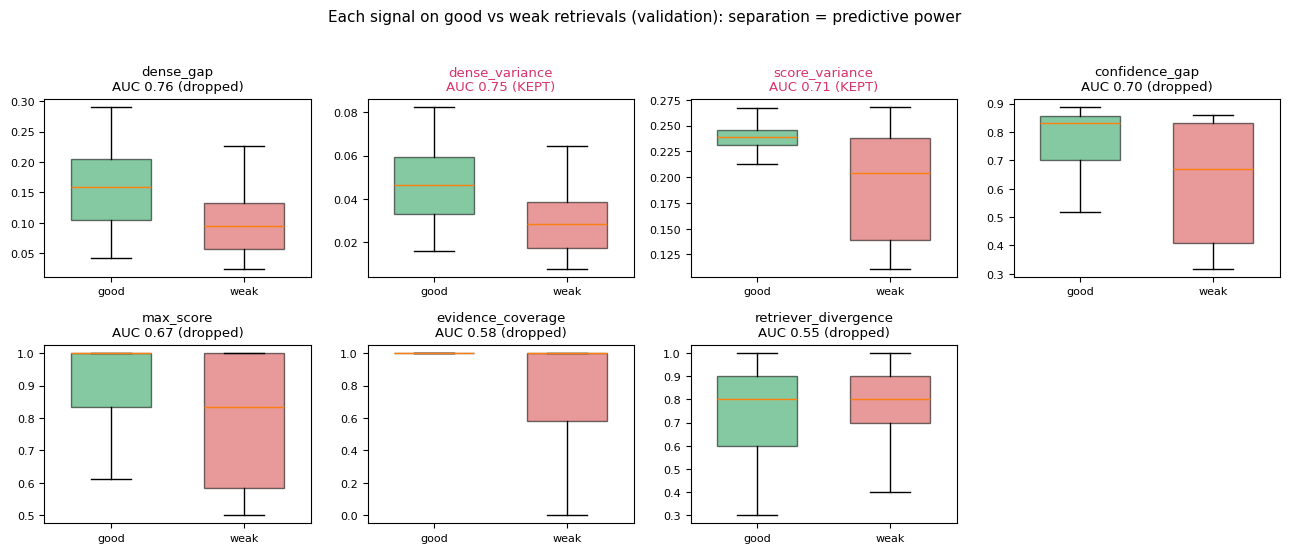

In [7]:
plot_signal_separation(calibration, aucs, kept, SIGNAL_COLUMN)

Two cleared the bar here and held up on a held-out validation split: `dense_variance` and
`score_variance`. The lesson to internalize: **the winners are corpus-specific.** On your data the
AUCs land differently, a signal weak here may be strong, and a different set may survive. The
method transfers, the selection does not: build the candidates, score each against your golden set,
drop the redundant ones, keep what separates.

### The gate

The gate is just those two signals against their floors: escalate if **either** fires. (That is
why the assembled loop later can escalate on `score_variance` even when `dense_variance` looks
fine.)

In [8]:
def retrieval_is_weak(question):
    # the tier-1 gate: escalate if EITHER kept signal is below its calibrated floor.
    dense_variance, score_variance = confidence_signals(question)
    return dense_variance < th["dense_variance"] or score_variance < th["score_variance"]

Calibrating the primary floor (`dense_variance`): the left panel shows where it sits on the good
vs weak distributions (escalate to its left); the right panel shows the precision/recall tradeoff
as you slide it. `score_variance` works the same way.

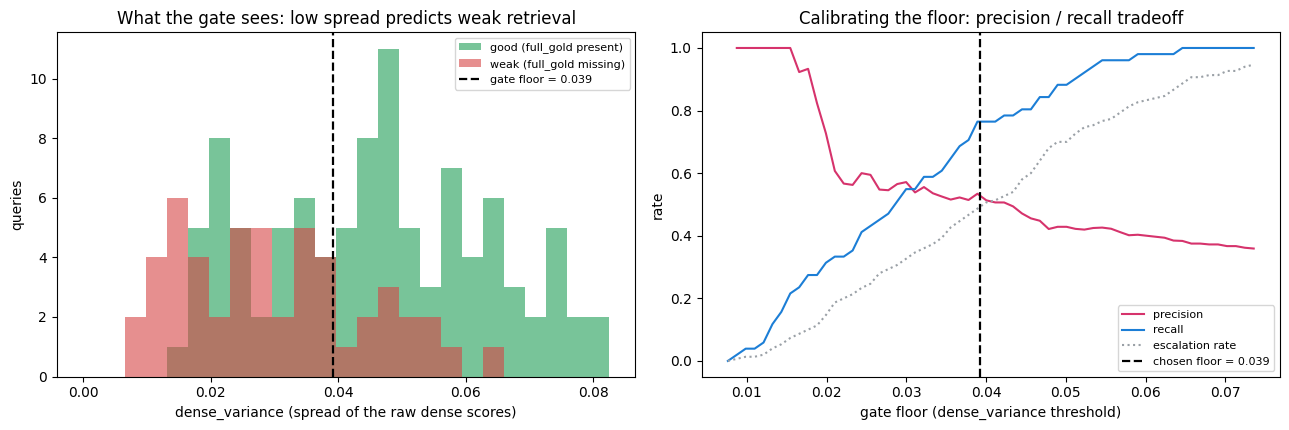

In [9]:
plot_gate(calibration, th["dense_variance"])

Nothing to change here: this reports the exact precision and recall at the calibrated floor. Set
`floor` to a different number and re-run to read any point on the curve above (no Qdrant calls;
all from the cached features).

In [10]:
retrieval_was_weak = [row["full_gold_label"] == 0 for row in calibration]
dense_spread = [row["dense_variance"] for row in calibration]

def precision_recall_at(floor):
    predicted_weak = [spread < floor for spread in dense_spread]
    true_pos  = sum(p and w for p, w in zip(predicted_weak, retrieval_was_weak))
    false_pos = sum(p and not w for p, w in zip(predicted_weak, retrieval_was_weak))
    false_neg = sum((not p) and w for p, w in zip(predicted_weak, retrieval_was_weak))
    precision = true_pos / (true_pos + false_pos) if (true_pos + false_pos) else float("nan")
    recall    = true_pos / (true_pos + false_neg) if (true_pos + false_neg) else float("nan")
    return precision, recall, sum(predicted_weak) / len(predicted_weak)

floor = th["dense_variance"]              # the calibrated floor (default). Optional: try floor = 0.05 and re-run.
precision, recall, escalation_rate = precision_recall_at(floor)
print(f"dense_variance floor = {floor}")
print(f"  precision       = {precision:.3f}   (of the queries we escalate, how many were truly weak)")
print(f"  recall          = {recall:.3f}   (of the truly weak queries, how many we catch)")
print(f"  escalation rate = {escalation_rate:.2f}   (fraction of queries sent past tier 1)")

dense_variance floor = 0.03927
  precision       = 0.527   (of the queries we escalate, how many were truly weak)
  recall          = 0.765   (of the truly weak queries, how many we catch)
  escalation rate = 0.49   (fraction of queries sent past tier 1)


## CP3: the corrective tiers, run live

Each rung is matched to a failure mode. A weak **single-hop** lookup is mis-ranked (a *precision*
problem); a weak **multi-hop** query is missing a hop (a *recall* problem).

### Tier 2: ColBERT late interaction (single-hop precision)

ColBERT scores a query against a passage **token by token** (MaxSim over Qdrant native
multivectors), catching term-level matches a single pooled embedding blurs away. Here is the
actual Qdrant call: prefetch a dense pool, then rescore it with the ColBERT multivector.

In [11]:
def colbert_rerank(question, limit=10):
    # Qdrant native multivector: prefetch a dense pool, rescore with ColBERT MaxSim (late interaction).
    dense, _bm25, _minicoil = retrieval.encode_query(question)
    colbert_vecs = [v.tolist() for v in next(iter(retrieval.get_colbert_model().query_embed(question)))]
    return client.query_points(
        config.COLBERT_COLLECTION,
        prefetch=[models.Prefetch(query=dense, using=config.DENSE_VEC, limit=50)],
        query=colbert_vecs, using=config.COLBERT_VEC, limit=limit, with_payload=True,
    ).points

tier2 = by_id["2hop__82744_23140__h0"]            # a weak single-hop lookup
gold = tier2["gold_doc_ids"]
print(f"Q: {tier2['question']}\n")
print("hybrid retrieve, supporting passage buried:")
show_hits(hybrid_search(tier2["question"]), gold)
print("\nColBERT late interaction, the right passage promoted:")
show_hits(colbert_rerank(tier2["question"]), gold)

Q: what country has the largest economy in africa

hybrid retrieve, supporting passage buried:
  [    ] #1  Nigeria
            As of 2015[update], Nigeria is the world's 20th largest economy, worth more than $500 billion a...
  [    ] #2  Nigeria
            Nigeria was ranked 30th in the world in terms of GDP (PPP) in 2012. Nigeria is the United State...
  [    ] #3  Nigeria
            Nigeria is often referred to as the "Giant of Africa", owing to its large population and econom...

ColBERT late interaction, the right passage promoted:
  [GOLD] #1  List of African countries by GDP (nominal)
            2017 Rank Country Nominal GDP ($billions) Nominal GDP per capita (US $) Notes Nigeria 376.284 1...
  [    ] #2  Nigeria
            As of 2015[update], Nigeria is the world's 20th largest economy, worth more than $500 billion a...
  [    ] #3  Namibia
            In 2013, global business and financial news provider, Bloomberg, named Namibia the top emerging...


Hybrid matched the entity "Nigeria" and buried the passage that actually answers the question (the
GDP table) at rank 7; ColBERT pulled it to rank 1. Across the validation set ColBERT is a wash *on
average* (single-hop is already mostly solved), but on the weak lookups the gate routes to it, it
lifts precision. A cross-encoder reranker ties ColBERT here; we use ColBERT because it is a native
Qdrant multivector. On your data, test both.

### Tier 3: decompose (IRCoT) for multi-hop recall

No reranking can fix a *missing* hop. Decompose is the automated version of the two-hop walk you
did in CP1: retrieve, let the LLM read the evidence and ask the next still-missing sub-question,
retrieve that, and union the evidence. Here is the loop, run live on the Jim Wilson question:

In [12]:
def decompose(question, max_hops=4):
    # IRCoT: retrieve, ask the next missing sub-question, retrieve, union. Repeat until ENOUGH.
    results = [retrieval.search(question, mode="hybrid", k=10)]   # retrieval.search == the hybrid query above, packaged
    sub_queries = []
    for _ in range(max_hops - 1):
        next_q, _tokens = agent.next_subquery(question, results, sub_queries)   # the LLM reads evidence, asks the next hop
        if next_q is None:
            break
        sub_queries.append(next_q)
        results.append(retrieval.search(next_q, mode="hybrid", k=10))
    return retrieval.union_pool(results, 10), sub_queries

multi = by_id["2hop__615262_131886"]
gold = multi["gold_doc_ids"]
print(f"Q: {multi['question']}\n")
print("hybrid retrieve (single pass), only the first hop is reachable:")
show_hits(hybrid_search(multi["question"]), gold)

pool, sub_queries = decompose(multi["question"])
print("\ndecompose reads hop 1, then asks the still-missing sub-question:")
for sub_question in sub_queries:
    print(f"  -> {sub_question}")
print("\nunioned evidence, the second supporting passage now in context:")
show_hits(pool, gold, k=4)

Q: What sea washes on the shores of the birthplace of Jim Wilson?

hybrid retrieve (single pass), only the first hop is reachable:
  [GOLD] #1  Jim Wilson (Northern Ireland politician)
            Born in County Antrim, Wilson attended Belfast College of Technology before becoming a marine e...
  [    ] #2  Beaufort Sea
            The Beaufort Sea () is a marginal sea of the Arctic Ocean, located north of the Northwest Terri...
  [    ] #3  How to Train Your Dragon
            The first book in the series, following Hiccup as he captures a dragon as a rite of passage and...



decompose reads hop 1, then asks the still-missing sub-question:
  -> What sea washes the shores of County Antrim?

unioned evidence, the second supporting passage now in context:
  [GOLD] #1  Jim Wilson (Northern Ireland politician)
            Born in County Antrim, Wilson attended Belfast College of Technology before becoming a marine e...
  [GOLD] #2  County Antrim
            In ancient times, Antrim was inhabited by a Celtic people called the Darini. In the early Middl...
  [    ] #3  Toome Upper
            Toome Upper is a barony in County Antrim, Northern Ireland. To its south lies Lough Neagh, and ...
  [    ] #4  Beaufort Sea
            The Beaufort Sea () is a marginal sea of the Arctic Ocean, located north of the Northwest Terri...


The hybrid pass found the Jim Wilson passage (its snippet names County Antrim); decompose asked the
follow-up and pulled in the passage about its sea. Now the aggregate, measured across the
validation set with a per-query counterfactual.

In [13]:
policy_comparison = load_artifact("policy_comparison_val.json")
overall = policy_comparison["overall"]
multi_hop = policy_comparison["by_type"]["multi_hop"]

pd.DataFrame([
    {"policy": "always-answer (baseline)", "single-hop recall@3": overall["always_answer"]["recall@3"],
     "single-hop MRR": overall["always_answer"]["mrr"], "multi-hop full_gold@3": multi_hop["always_answer"]["full_gold@3"]},
    {"policy": "always-ColBERT", "single-hop recall@3": overall["always_colbert"]["recall@3"],
     "single-hop MRR": overall["always_colbert"]["mrr"], "multi-hop full_gold@3": multi_hop["always_colbert"]["full_gold@3"]},
    {"policy": "always-decompose", "single-hop recall@3": overall["always_decompose"]["recall@3"],
     "single-hop MRR": overall["always_decompose"]["mrr"], "multi-hop full_gold@3": multi_hop["always_decompose"]["full_gold@3"]},
])

,policy,single-hop recall@3,single-hop MRR,multi-hop full_gold@3
0,always-answer (baseline),0.789,0.859,0.18
1,always-ColBERT,0.799,0.870,0.22
2,always-decompose,0.871,0.874,0.48


## The assembled loop: `solve()`

Now put it together. The whole agent is this one function: retrieve, read the signal, climb only
as far as the query needs. Every piece below is something you built above.

In [14]:
def to_passages(points):
    # wrap raw Qdrant points as the lightweight passage objects the answerer reads.
    return [retrieval.Candidate(doc_id=p.id, title=p.payload["title"], text=p.payload["text"],
                                score=p.score, supports=p.payload.get("supports", [])) for p in points]

def looks_multi_hop(question):
    # cheap, gold-free router: >= 2 named entities or a long question -> likely a missing hop.
    return len(signals.question_entities(question)) >= 2 or len(question.split()) >= 12

def solve(question):
    # the self-correcting retrieval loop (Decision A: the cost-escalation ladder).
    if not retrieval_is_weak(question):
        return to_passages(hybrid_search(question)), "tier 1: confident, answer from the hybrid top-3"
    if looks_multi_hop(question):
        pool, sub_queries = decompose(question)
        return pool, f"tier 3: weak + multi-hop, decomposed ({len(sub_queries)} sub-question(s))"
    return to_passages(colbert_rerank(question)), "tier 2: weak single-hop, ColBERT late-interaction"

Three queries, three paths from one agent. Each answer is generated from the routed top-3 (the LLM
self-abstains if the evidence is not enough), so this runs the full loop live.

In [15]:
routing_demos = [
    ("confident single-hop", "2hop__101521_42157__h0"),
    ("weak single-hop",      "2hop__130545_45439__h0"),
    ("multi-hop",            "2hop__615262_131886"),
]
for label, qid in routing_demos:
    q = by_id[qid]
    pool, route = solve(q["question"])
    answer, _tokens = agent.generate_answer(q["question"], pool[:config.ANSWER_K])
    print(f"[{label}]")
    show_run(q["question"], route, answer, pool, q["gold_doc_ids"])

[confident single-hop]
Q: Which continent is Atbarah River located?
  route:  tier 1: confident, answer from the hybrid top-3
  answer: Africa
  gold in the answer context: 1/1



[weak single-hop]
Q: What state is Chesapeake City Bridge located?
  route:  tier 2: weak single-hop, ColBERT late-interaction
  answer: Maryland
  gold in the answer context: 1/1



[multi-hop]
Q: What sea washes on the shores of the birthplace of Jim Wilson?
  route:  tier 3: weak + multi-hop, decomposed (1 sub-question(s))
  answer: Irish Sea
  gold in the answer context: 2/2



The cheap query answered at tier 1, the weak lookup escalated to ColBERT, the multi-hop decomposed.
The signal decides how far to climb, so each query pays only for the correction it needs. Now the
cost/quality frontier across the validation set (cost = mean LLM sub-query calls per query;
decompose is the expensive rung; ColBERT adds a retrieval pass, not an LLM call, so it reads ~0
here).

In [16]:
frontier_validation = frontier_table(overall, mrr_key="mrr", cost_key="cost_llm")
frontier_validation

,policy,recall@3,full_gold@3,MRR,LLM calls/query
0,always-answer,0.789,0.673,0.859,0.000
1,always-colbert,0.799,0.693,0.870,0.000
2,always-decompose,0.871,0.787,0.874,1.047
3,ladder,0.852,0.753,0.910,0.467


Read this as a cost/quality tradeoff, not a single winner. The ladder reaches about the same
answerable quality as always-decompose at **under half** its LLM cost. It **leads on MRR**;
always-decompose **leads on full_gold@3** (completeness). The ladder does not dominate: it is the
efficient point.

## The STOP decision: a smaller, separate lever

Stopping is a different decision from routing: whether to answer at all or abstain. The **gentle
stop** is the default (the generator answers, or says it lacks enough), and it keeps the most
answers. For workloads where abstaining out of caution beats a confident wrong answer, swap in an
**LLM sufficiency check**: it catches far more unanswerables but over-refuses some answerables.

In [17]:
stop_variants = load_artifact("targeted_stop_v25.json")["variants"]
stop_rows = [
    ("hybrid baseline + gentle",       "baseline_hybrid_gentle"),
    ("ladder + gentle (default)",      "ladder_gentle"),
    ("ladder + LLM sufficiency check", "ladder_autorater_all"),
]
pd.DataFrame([
    {"setup": label,
     "catches unanswerable": stop_variants[key]["abstain_unans"],
     "over-refuses answerable": stop_variants[key]["false_stop_ans"],
     "full workload handled": stop_variants[key]["selective_accuracy"]}
    for label, key in stop_rows
])

,setup,catches unanswerable,over-refuses answerable,full workload handled
0,hybrid baseline + gentle,0.546,0.211,0.530
1,ladder + gentle (default),0.411,0.150,0.498
2,ladder + LLM sufficiency check,0.865,0.411,0.629


"Full workload handled" counts a query as handled when the agent answers correctly OR correctly
refuses an unanswerable. Routing is not stopping: a good router is not automatically a good
stopper, and the ceiling on either is retrieval completeness. Here is the gentle stop on an
unanswerable, run live: the agent decomposes, finds no sufficient evidence, and abstains.

In [18]:
unanswerable = by_id["2hop__108098_170204"]
pool, route = solve(unanswerable["question"])
answer, _tokens = agent.generate_answer(unanswerable["question"], pool[:config.ANSWER_K])
show_run(unanswerable["question"], route, answer, pool, [])

Q: Who is the brother of the painter of Metaphysical Interior with Biscuits?
  route:  tier 3: weak + multi-hop, decomposed (2 sub-question(s))
  answer: INSUFFICIENT_CONTEXT



## Wrap: the honest scorecard (held-out test)

The adaptive ladder against the fixed policies on the test slice. We lead with retrieval precision
(the contamination-resistant measure of what the loop fixes) and report answer quality with a
semantic judge, not exact match. Honest caveat: this test slice partly reuses questions from
earlier rounds (disclosed in `headline_final_v25.json`), so treat it as held-out from threshold
tuning, not as a pristine never-seen set.

In [19]:
headline = load_artifact("headline_final_v25.json")
frontier_test = frontier_table(headline["overall"], mrr_key="mrr_first", cost_key="llm_calls")
frontier_test

,policy,recall@3,full_gold@3,MRR,LLM calls/query
0,always-answer,0.817,0.700,0.880,0.000
1,always-colbert,0.802,0.683,0.892,0.000
2,always-decompose,0.877,0.794,0.901,1.883
3,ladder,0.852,0.761,0.913,0.778


In [20]:
ci_vs_baseline = headline["ci_vs"]["always_answer"]
print("ladder vs baseline lift (paired bootstrap, 95% CI):\n")
for metric in ("recall@3", "full_gold@3"):
    lift = ci_vs_baseline[metric]["lift"]
    low, high = ci_vs_baseline[metric]["ci95"]
    print(f"  {metric:12s} {lift:+.4f}   CI95 [{low:+.4f}, {high:+.4f}]   {'clears 0' if low > 0 else 'crosses 0'}")

ladder vs baseline lift (paired bootstrap, 95% CI):

  recall@3     +0.0356   CI95 [+0.0032, +0.0676]   clears 0
  full_gold@3  +0.0611   CI95 [+0.0111, +0.1111]   clears 0


Answer quality uses a **gpt-5.5 semantic judge** (it credits correct-but-paraphrased answers), not
exact match.

In [21]:
judge = load_artifact("judge_eval_v25.json")
by_policy = judge["by_policy"]
answer_quality = pd.DataFrame([
    {"policy": name.replace("_", "-"),
     "overall": by_policy[name]["overall"]["judge"],
     "single-hop": by_policy[name]["single_hop"]["judge"],
     "multi-hop": by_policy[name]["multi_hop"]["judge"]}
    for name in ("always_answer", "ladder", "always_decompose")
])
answer_quality

,policy,overall,single-hop,multi-hop
0,always-answer,0.639,0.833,0.250
1,ladder,0.678,0.825,0.383
2,always-decompose,0.711,0.833,0.467


In [22]:
jc = judge["ci_ladder"]
print(f"ladder vs baseline:  {jc['vs_baseline']['lift']:+.3f}   CI95 {jc['vs_baseline']['ci95']}  (crosses 0, marginal)")
print(f"ladder vs decompose: {jc['vs_decompose']['lift']:+.3f}   (decompose answers best)")

ladder vs baseline:  +0.039   CI95 [-0.0111, 0.0889]  (crosses 0, marginal)
ladder vs decompose: -0.033   (decompose answers best)


### What we learned (and what we honestly did not)

- **Adaptive routing is cost-efficient, not dominant.** The ladder reaches near-decompose
  answerable quality at about 40% of always-decompose's LLM cost and beats the no-correction
  baseline on retrieval (CIs clear of zero). It leads MRR; always-decompose leads full_gold@3. It
  wins the cost/quality tradeoff, not every metric.
- **The gains are per-slice.** Decomposition lifts multi-hop full_gold and multi-hop answer quality
  by tens of points; the overall lift is small because the easy single-hop majority is already
  strong. That dilution *is* the cost story: easy queries stay cheap.
- **The right substrate makes a weak signal strong.** Reading spread on raw dense cosines, not the
  fused score, is what made the confidence gate work.
- **Routing is not stopping.** A real sufficiency check wins the full workload (about 0.63 vs the
  baseline's 0.53) but trades away some answers.
- **Honesty on decompose.** IRCoT's sub-queries are written by an LLM that may know the bridge
  entities, so its lift is an upper bound that shrinks on unseen corpora. Recalibrate on yours.

**What we tested that did NOT win here (but wins elsewhere):** `evidence_coverage` and
`retriever_divergence` (useful on single-hop / entity-lookup / lexical-mismatch data); `max_score`
(a calibrated single-retriever QPP signal); a cross-encoder reranker (tied ColBERT here); and the
recall@10 framing (it hid all the headroom, since single-hop is ~98% solved at top-10). None is
useless: each would win on a different workload.

### How to adapt this to your workflow

The numbers are ours; the method is yours. To build a self-correcting loop on your own corpus:

1. **Set your answer-context size.** Decide how many passages the LLM reads (we used top-3). That
   choice is what makes ranking precision matter and gives the rungs room to work.
2. **Build candidate signals and validate them.** Compute cheap query-time readings, score each
   against your golden set (AUC), drop the redundant twins, keep what separates on your data.
3. **Match each rung to a real failure mode.** Inspect your own traces, find your failure modes,
   and pick the cheapest action that fixes each.
4. **Measure on cost AND quality, per query.** Run every policy on every query, read the frontier,
   keep the loop only where it earns its cost.
5. **Choose your stop.** Gentle by default; an LLM sufficiency check when a confident wrong answer
   is more expensive than an honest abstention.

Take home: this notebook and the reusable `src/` modules (the same logic, packaged).